##  Project

The heart data set was used in the current project. This data set contains 4000 records and 16 variables. These variables are characterized participants of the study. The purpose of the is to investigate whether there is a risk of coronary heart disease within 10 years given such variables. This data set contains following variables:

Demographic:
1.	Sex of a participant male or female. 0-female. 1-male
2.	Age. This variable is expressed in whole numbers
3.  Education

Behavioral:
1.	currentSmoker. 0-non-smoker, 1-smoker
2.	cigsPerDay. This variable describes the number of cigarettes per day. Interval 0-20

Medical history: 
1.	BPmeds: whether or not the patient was on blood pressure medication, 0-no, 1-yes
2.	prevalentStroke: whether or not the patient had previously had a stroke, 0-no, 1-yes
3.	prevalentHyp: whether or not the patient was hypertensive, 0-no, 1-yes
4.	diabetes: whether or not the patient had diabetes, 0-no, 1-yes

Medical(current):
1.	totChol:total cholesterol level
2.	sysBP: systolic blood pressure
3.	diaBP: diastolic blood pressure
4.	BMI: Body Mass Index
5.	heartrate: heart rate
6.	glucose: glucose level

TenYearCHD: wether the coronary heart disease occurred within 10 years. 1 yes, 0-no


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from numpy import argmax
from sklearn.metrics import roc_curve

In [2]:
#import the heart data set and printing the first 5 rows
df=pd.read_csv("data/heart.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
#since education has no effect of heart disease the education variable will be removed from the data set
df1=df.drop(["education"], axis="columns")
df1.head()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
#the male variable will be changed for sex variable
df1=df1.rename(columns={"male":"sex"})
df1.head()



,sex,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df1.shape

(4240, 15)

In [6]:
#checking for NaN values
df1.isnull().sum()

sex                  0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Checking ratio of rows containing NaN values and total number of columns

In [7]:
na=[i for i in df1.isnull().sum(axis=1) if i>0]
na_row_ratio=len(na)/len(df1)
print("The ratio of rows containing NaN values and total number of columns is {}".format(na_row_ratio))

The ratio of rows containing NaN values and total number of columns is 0.11533018867924529


In [8]:
#since the fraction of rows containing NaN values is relatively low-0.127 all NaN containing rows could be dropped
df2=df1.dropna(axis=0)
df2.shape

(3751, 15)

In [9]:
# import matplotlib.pyplot as plt
# %matplotlib notebook
# fig=plt.figure(figsize=(20,30))
# for i, col in enumerate(df2.columns):
#     ax=fig.add_subplot(6, 3, i+1)
#     df2[col].hist(bins=20, ax=ax, facecolor="red")
#     ax.set_title(col+" Distribution",color='blue', fontsize=16, fontname="Arial")
# plt.savefig("distributions.jpg")

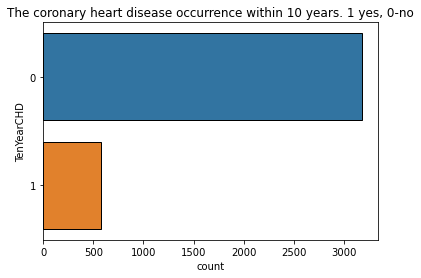

In [10]:
sn.countplot(y="TenYearCHD", data=df2, edgecolor=(0,0,0))
plt.title("The coronary heart disease occurrence within 10 years. 1 yes, 0-no")
plt.show()

In [11]:
print("There are {} participants who have not had heart attack for 10 years and \
       {} participants have had heart attack for 10 years".format(df2.TenYearCHD.value_counts()[0], \
                                                                     df2.TenYearCHD.value_counts()[1]))

There are 3179 participants who have not had heart attack for 10 years and        572 participants have had heart attack for 10 years


In [12]:

# sn.pairplot(data=df2)

In [13]:
round(df2.describe(), 2)


,sex,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00,3751.00
mean,0.45,49.57,0.49,9.01,0.03,0.01,0.31,0.03,236.93,132.37,82.94,25.81,75.70,81.88,0.15
std,0.50,8.57,0.50,11.93,0.17,0.07,0.46,0.16,44.61,22.05,11.93,4.07,11.96,23.88,0.36
min,0.00,32.00,0.00,0.00,0.00,0.00,0.00,0.00,113.00,83.50,48.00,15.54,44.00,40.00,0.00
25%,0.00,42.00,0.00,0.00,0.00,0.00,0.00,0.00,206.00,117.00,75.00,23.08,68.00,71.00,0.00
50%,0.00,49.00,0.00,0.00,0.00,0.00,0.00,0.00,234.00,128.00,82.00,25.41,75.00,78.00,0.00
75%,1.00,56.00,1.00,20.00,0.00,0.00,1.00,0.00,264.00,144.00,90.00,28.06,82.00,87.00,0.00
max,1.00,70.00,1.00,70.00,1.00,1.00,1.00,1.00,696.00,295.00,142.50,56.80,143.00,394.00,1.00


In [14]:
#calculating the correlation matrix
cor=df2.corr(method="pearson")
cor

,sex,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
sex,1.000000,-0.024142,0.203215,0.325886,-0.052355,-0.002513,0.003588,0.011834,-0.067595,-0.044515,0.053890,0.074868,-0.115444,0.003130,0.096000
age,-0.024142,1.000000,-0.211338,-0.188804,0.131690,0.050018,0.305292,0.109321,0.261443,0.388280,0.205191,0.136428,-0.005893,0.118529,0.231584
currentSmoker,0.203215,-0.211338,1.000000,0.773259,-0.051816,-0.037573,-0.105258,-0.045308,-0.049945,-0.133154,-0.114118,-0.165404,0.054924,-0.054078,0.021709
cigsPerDay,0.325886,-0.188804,0.773259,1.000000,-0.046625,-0.035713,-0.067470,-0.039436,-0.030600,-0.092310,-0.056202,-0.090525,0.067194,-0.055090,0.055920
BPMeds,-0.052355,0.131690,-0.051816,-0.046625,1.000000,0.111601,0.262955,0.056337,0.089625,0.269479,0.199282,0.105128,0.010228,0.052464,0.084740
prevalentStroke,-0.002513,0.050018,-0.037573,-0.035713,0.111601,1.000000,0.065169,0.009423,0.012297,0.060421,0.055189,0.035568,-0.016673,0.015789,0.047684
prevalentHyp,0.003588,0.305292,-0.105258,-0.067470,0.262955,0.065169,1.000000,0.082030,0.164645,0.697849,0.616753,0.303411,0.142013,0.085776,0.178615
diabetes,0.011834,0.109321,-0.045308,-0.039436,0.056337,0.009423,0.082030,1.000000,0.047453,0.104393,0.051761,0.093098,0.063370,0.616087,0.093222
totChol,-0.067595,0.261443,-0.049945,-0.030600,0.089625,0.012297,0.164645,0.047453,1.000000,0.216375,0.169811,0.119651,0.094795,0.046902,0.089613
sysBP,-0.044515,0.388280,-0.133154,-0.092310,0.269479,0.060421,0.697849,0.104393,0.216375,1.000000,0.785853,0.330484,0.181381,0.132878,0.220108


<AxesSubplot:>

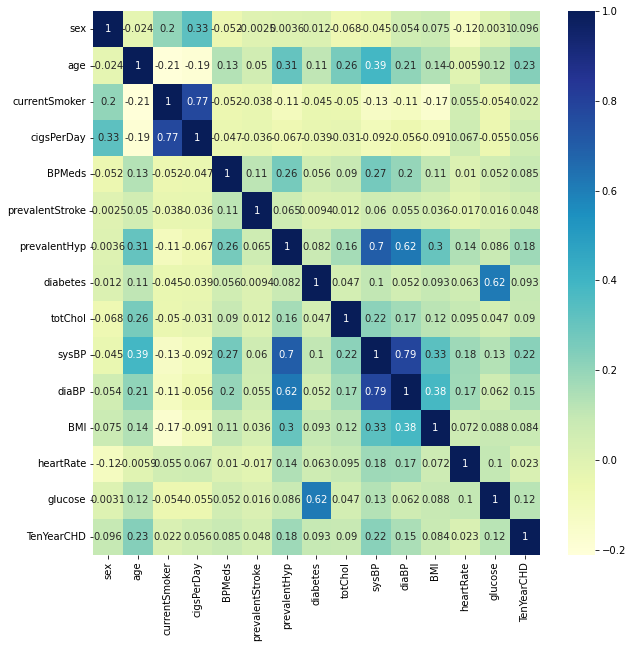

In [15]:
#visualization of the correlation matrix
plt.rcParams["figure.figsize"]=(10, 10)
sn.heatmap(data=cor, annot=True, cmap="YlGnBu")

In [16]:
"""defining the correlation function that returns highly correlated features.
This function has two arguments"""
def correlation(dataset, threshold):
    col_corr=[]
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range (i):
            if abs(corr_matrix.iloc[i, j])>threshold:
                colname=corr_matrix.columns[j]
                rowname=corr_matrix.index[i]
                col_corr.append((colname, rowname))
    return col_corr
corr_col=correlation(df2, 0.7)
print("Highly correlated variables are ", corr_col)

Highly correlated variables are  [('currentSmoker', 'cigsPerDay'), ('sysBP', 'diaBP')]


### Logistic regression model

In [17]:
labels=df2["TenYearCHD"]
features=df2.drop(columns=["TenYearCHD"])
features.head()

,sex,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0


In [18]:
X_train, X_test, y_train, y_test=train_test_split(features, labels, test_size=0.25, random_state=1000, stratify=labels)

In [19]:
model=Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(solver="lbfgs", random_state=1000))
]).fit(X_train, y_train)

In [20]:
model["lr"].get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 1000,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [21]:
model["lr"].coef_

array([[ 0.2238459 ,  0.51676375,  0.05812159,  0.28002802, -0.04756368,
         0.06962624,  0.1821034 ,  0.03764098,  0.11198302,  0.35353272,
        -0.12346759,  0.07014625, -0.03847045,  0.17706862]])

In [22]:
model["lr"].intercept_

array([-1.99015032])

In [23]:
predicted_labels=model.predict(X_test)

In [24]:
def confusion_matrix_visual(y_true, y_pred, class_labels, ax=None, title=None, **kwargs):
    """y_test: true labels for y
       y_pred: predicted labels for y
       class_labels: labels of differemt classes
       ax: matplotlib axes
       title: the plot title
       **kwargs: additional arguments in the form of a dictionary"""
    matrix=confusion_matrix(y_true, y_pred)
    ax=sn.heatmap(matrix.T, square=True, annot=True, fmt="d", cmap=plt.cm.Blues, ax=ax,  **kwargs)
    ax.set_xlabel("Actual", fontsize=14)
    ax.set_ylabel("Model Prediction", fontsize=14)
    tick_marks=np.arange(len(class_labels))+0.5
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_labels, fontsize=14)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_labels, rotation=0, fontsize=14)
    ax.set_title("Confusion matrix", fontsize=16)
    return ax

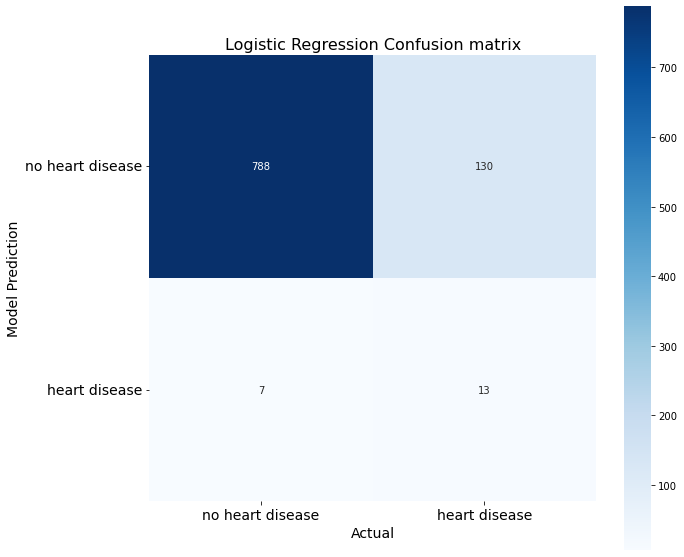

In [25]:
confusion_matrix_visual(y_test, predicted_labels, ["no heart disease", "heart disease"])
plt.title("Logistic Regression Confusion matrix", fontsize=16)
plt.show()

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       795
           1       0.65      0.09      0.16       143

    accuracy                           0.85       938
   macro avg       0.75      0.54      0.54       938
weighted avg       0.83      0.85      0.80       938



In [27]:
model["lr"]

LogisticRegression(random_state=1000)

#### Tuning the logistic regression model

#### Dispaying ROC curve

In [28]:
y_pred=model.predict_proba(X_test)
#making 1D array
y_pred1 = y_pred[:, 1]
y_pred1[:10]

array([0.19789387, 0.09546097, 0.09556916, 0.14619329, 0.03665845,
       0.1174938 , 0.27909779, 0.07389401, 0.05543246, 0.30140409])

In [29]:
#frp: False positive rate.
#trp:True positive rate.
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred1)
roc_auc = metrics.auc(fpr, tpr)

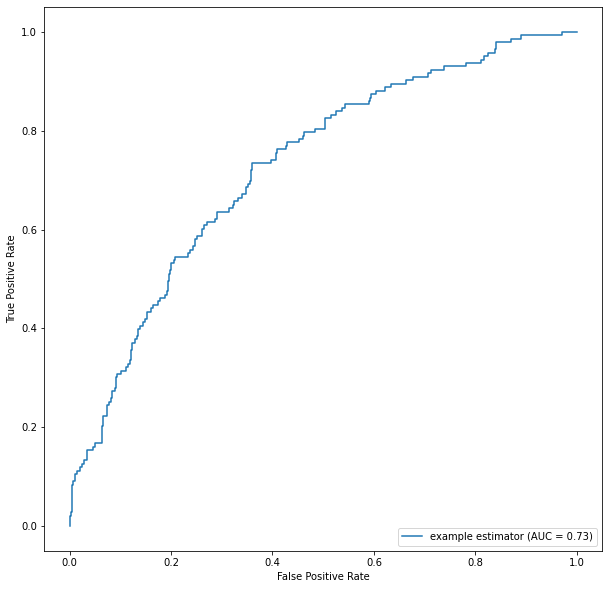

In [30]:
#making ROC curve
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()


We need to find threshold corresponding to the maximun of tpr-fpr

In [31]:
y_pred1 = y_pred[:, 1]
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred1)
J = tpr - fpr
#calculation of index corresponding to the maximum difference of true positive rate and 
#false positive rate
ix = argmax(J)
best_thresh = thresholds[ix]
print('Best Threshold=%f' % (best_thresh))
#decisions is an array of predicted probabilities for X_test for the best threshold
decisions = (model.predict_proba(X_test) >= best_thresh).astype(int)
decisions=decisions[:, 1]
# print(J)
print(argmax(J))
# print(thresholds)
# print(best_thresh)
# decisions

Best Threshold=0.141161
149


In [32]:
decisions[:10]

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1])

In [33]:
print(classification_report(y_test, decisions))

              precision    recall  f1-score   support

           0       0.93      0.64      0.76       795
           1       0.27      0.73      0.39       143

    accuracy                           0.65       938
   macro avg       0.60      0.69      0.58       938
weighted avg       0.83      0.65      0.70       938



#### Conclusion: Using the best threshold obtained from ROC curve greatly improved the model performance in terms of
#### heart disease prediction:
#### default threshold (0.5):  recall(0)=0.99 recall(1)=0.09
#### the best threshold(0.14): recall(0)=0.64 recall(1)=0.73 
#### 0-no heart disease 1-heart disease 